In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".zip"):
            print(os.path.join(root, file))

/content/drive/MyDrive/archive.zip


In [7]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    if len(files) > 0:
        print("Sample files:", files[:5])
    print("-" * 50)

/content/dataset
--------------------------------------------------
/content/dataset/test
--------------------------------------------------
/content/dataset/test/test
Sample files: ['978.jpg', '11911.jpg', '7523.jpg', '7605.jpg', '6193.jpg']
--------------------------------------------------
/content/dataset/train
--------------------------------------------------
/content/dataset/train/train
Sample files: ['dog.7407.jpg', 'cat.2302.jpg', 'cat.8335.jpg', 'cat.9867.jpg', 'dog.3078.jpg']
--------------------------------------------------


In [9]:
import os
import shutil

# Paths
source_folder = "/content/dataset/train/train"

cat_folder = "/content/dataset/data/cats"
dog_folder = "/content/dataset/data/dogs"

# Create folders
os.makedirs(cat_folder, exist_ok=True)
os.makedirs(dog_folder, exist_ok=True)

# Move images
for file in os.listdir(source_folder):
    if file.startswith("cat"):
        shutil.copy(os.path.join(source_folder, file), cat_folder)
    elif file.startswith("dog"):
        shutil.copy(os.path.join(source_folder, file), dog_folder)

print("Cats and Dogs folders created successfully!")

Cats and Dogs folders created successfully!


In [10]:
train_path = "/content/dataset/data"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [11]:
vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(150, 150, 3)
)

# Freeze VGG16 layers
for layer in vgg.layers:
    layer.trainable = False

print("VGG16 Loaded Successfully!")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 Loaded Successfully!


In [12]:
model = Sequential()

model.add(vgg)
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,763,521 (60.13 MB)

 Trainable params: 1,048,833 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
from tensorflow.keras.optimizers import SGD

In [14]:
model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [15]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 126ms/step - accuracy: 0.7428 - loss: 0.5129 - val_accuracy: 0.8358 - val_loss: 0.3978
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 128ms/step - accuracy: 0.8303 - loss: 0.3846 - val_accuracy: 0.8628 - val_loss: 0.3358
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.8529 - loss: 0.3424 - val_accuracy: 0.8740 - val_loss: 0.3072
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.8601 - loss: 0.3219 - val_accuracy: 0.8780 - val_loss: 0.2914
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.8729 - loss: 0.3049 - val_accuracy: 0.8854 - val_loss: 0.2784


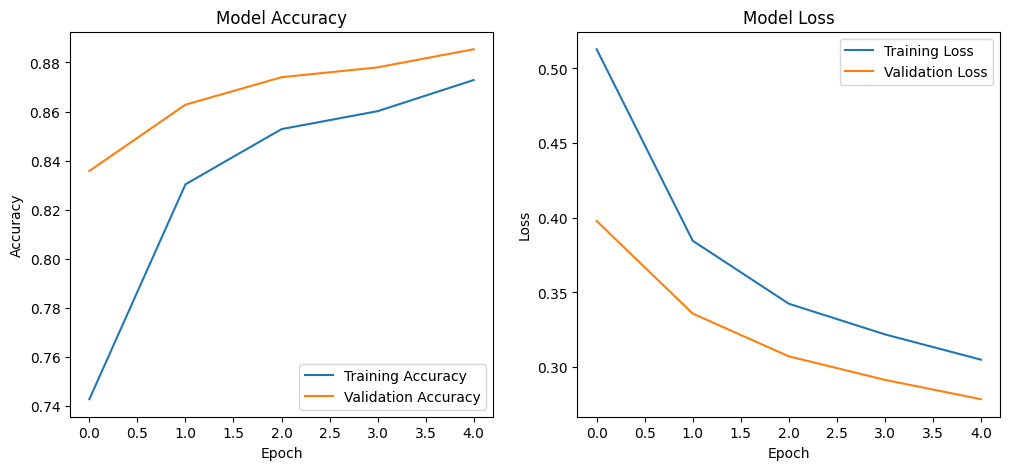

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [18]:
model.save("cats_dogs_vgg16.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [25]:
from google.colab import files

uploaded = files.upload()

Saving images_043_un5E.jpg to images_043_un5E.jpg


In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Dog")
    print("Confidence:", prediction[0][0])
else:
    print("Prediction: Cat")
    print("Confidence:", 1 - prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: Cat
Confidence: 0.96714735


In [27]:
from google.colab import files

uploaded = files.upload()

Saving faviconV2_011_FB-I.png to faviconV2_011_FB-I (1).png


In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Dog")
    print("Confidence:", prediction[0][0])
else:
    print("Prediction: Cat")
    print("Confidence:", 1 - prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction: Dog
Confidence: 0.7184451
